In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])
print("Input:\n",X)
print("Output:\n",y)

Input:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output:
 [[0]
 [1]
 [1]
 [0]]


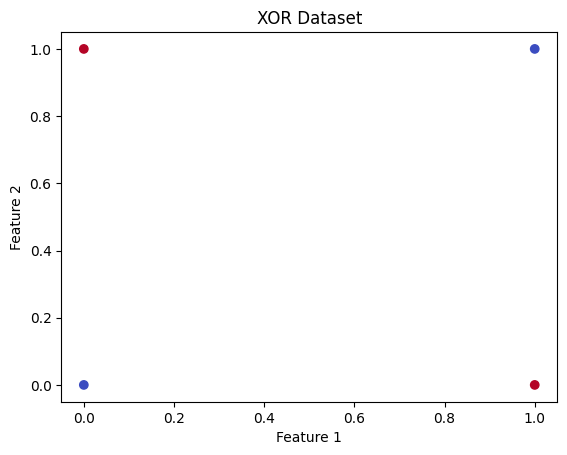

In [4]:
plt.scatter(X[:,0],X[:,1], c=y.flatten(), cmap='coolwarm')
plt.title("XOR Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [5]:
np.random.seed(42)

input_size = 2
hidden_size = 3
output_size = 1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

print("W1:\n",W1)
print("W2:\n",W2)

W1:
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]
W2:
 [[ 1.57921282]
 [ 0.76743473]
 [-0.46947439]]


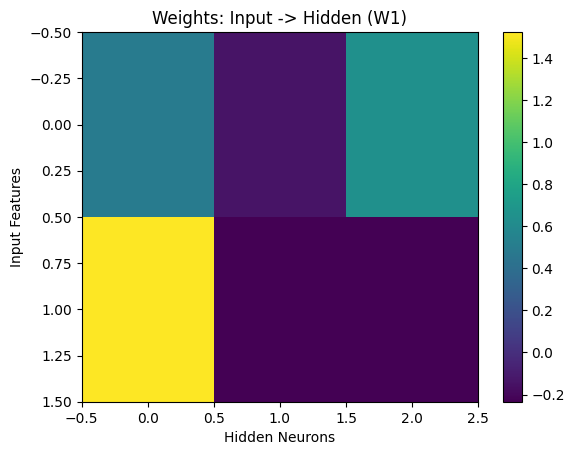

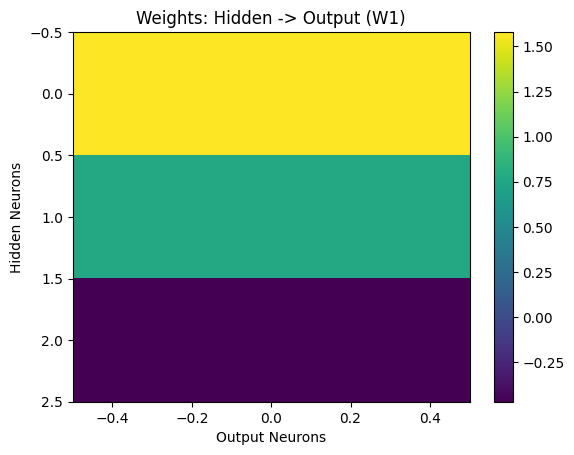

In [6]:
plt.imshow(W1,aspect='auto')
plt.colorbar()
plt.title("Weights: Input -> Hidden (W1)")
plt.xlabel("Hidden Neurons")
plt.ylabel("Input Features")
plt.show()

plt.imshow(W2,aspect='auto')
plt.colorbar()
plt.title("Weights: Hidden -> Output (W1)")
plt.xlabel("Output Neurons")
plt.ylabel("Hidden Neurons")
plt.show()

In [7]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [8]:
def forward(X):
  z1 = np.dot(X,W1) + b1
  a1 = sigmoid(z1)

  z2 = np.dot(a1,W2) + b2
  a2 = sigmoid(z2)

  return z1, a1, z2, a2

In [9]:
z1, a1, z2, output = forward(X)

print("Hidden Layer Output:\n",a1)
print("Final Output:\n",output)

Hidden Layer Output:
 [[0.5        0.5        0.5       ]
 [0.82098421 0.44172766 0.44173171]
 [0.62168683 0.46548889 0.65648939]
 [0.88285454 0.40795696 0.60193917]]
Final Output:
 [[0.71881406]
 [0.80660888]
 [0.73707158]
 [0.80607425]]


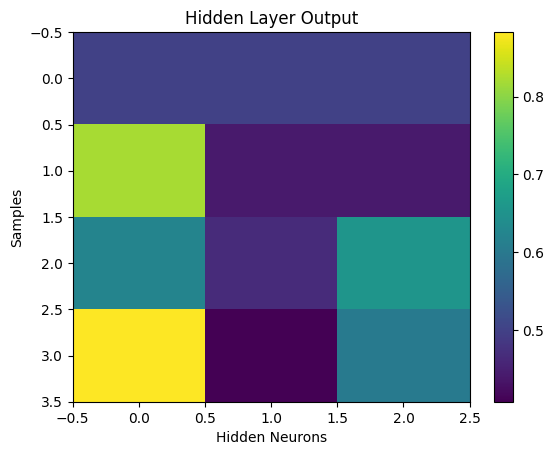

In [10]:
plt.imshow(a1, aspect='auto')
plt.colorbar()
plt.title("Hidden Layer Output")
plt.xlabel("Hidden Neurons")
plt.ylabel("Samples")
plt.show()

In [12]:
for i in range(len(X)):
  print(f"\nInput: {X[i]}")
  print(f"Hidden Activation: {a1[i]}")
  print(f"Final Output: {output[i]}")


Input: [0 0]
Hidden Activation: [0.5 0.5 0.5]
Final Output: [0.71881406]

Input: [0 1]
Hidden Activation: [0.82098421 0.44172766 0.44173171]
Final Output: [0.80660888]

Input: [1 0]
Hidden Activation: [0.62168683 0.46548889 0.65648939]
Final Output: [0.73707158]

Input: [1 1]
Hidden Activation: [0.88285454 0.40795696 0.60193917]
Final Output: [0.80607425]


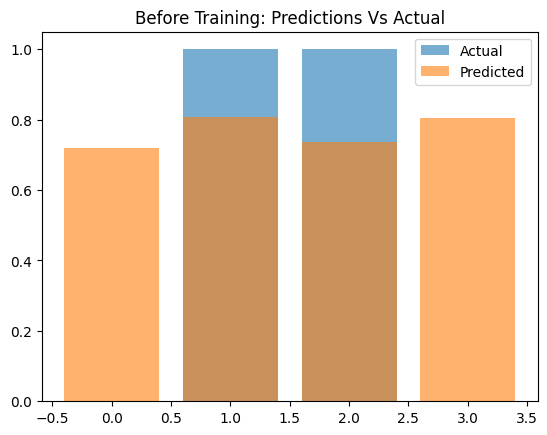

In [14]:
plt.bar(range(len(y)),y.flatten(),alpha=0.6,label='Actual')
plt.bar(range(len(output)), output.flatten(),alpha=0.6,label='Predicted')
plt.legend()
plt.title("Before Training: Predictions Vs Actual")
plt.show()

In [15]:
loss = np.mean((y - output)**2)
print("Loss:",loss)

Loss: 0.31824520886068175


In [17]:
learning_rate = 0.1
losses = []

for epoch in range(10000):
  z1,a1,z2,output = forward(X)

  loss = np.mean((y-output)**2)
  losses.append(loss)

  error = y-output

  d_output = error*output*(1-output)
  d_hidden = d_output.dot(W2.T)*a1*(1-a1)

  W2 += a1.T.dot(d_output)*learning_rate
  W1 += X.T.dot(d_hidden)*learning_rate

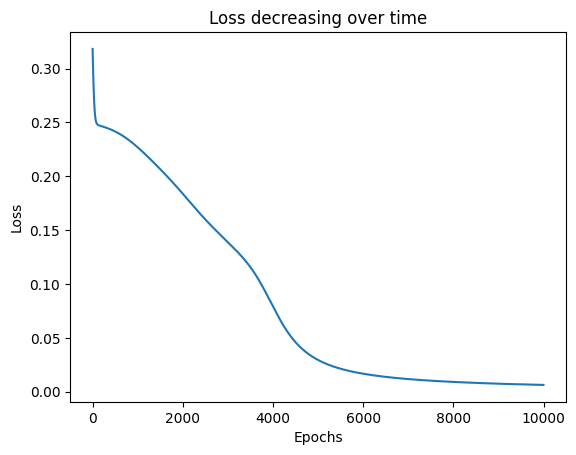

In [18]:
plt.plot(losses)
plt.title("Loss decreasing over time")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [19]:
_,_,_,predictions = forward(X)
print("Predictions:\n",predictions)

Predictions:
 [[0.10846339]
 [0.92615799]
 [0.92496146]
 [0.05022337]]


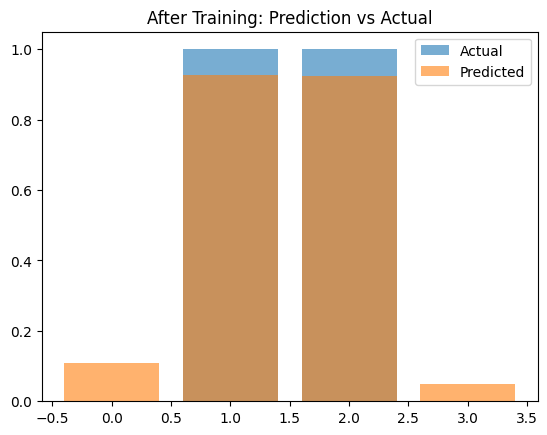

In [20]:
plt.bar(range(len(y)),y.flatten(),alpha=0.6,label='Actual')
plt.bar(range(len(predictions)), predictions.flatten(),alpha=0.6,label='Predicted')
plt.legend()
plt.title("After Training: Prediction vs Actual")
plt.show()

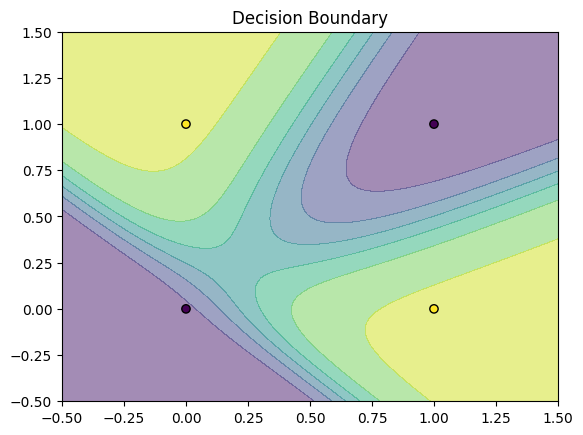

In [23]:
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,100),
                     np.linspace(-0.5,1.5,100))

grid = np.c_[xx.ravel(),yy.ravel()]
_,_,_,preds = forward(grid)

z = preds.reshape(xx.shape)

plt.contourf(xx,yy,z,alpha=0.5)
plt.scatter(X[:,0],X[:,1], c=y.flatten(),edgecolors='k')
plt.title("Decision Boundary")
plt.show()